<a href="https://colab.research.google.com/github/Prasanna-datascience/Data201Class/blob/main/week-02/Week_2_Lab_Intro_to_Python_Prasanna.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Part 1 - College Dataset Review

                     Unnamed: 0 Private  Apps  Accept  Enroll  Top10perc  \
0  Abilene Christian University     Yes  1660    1232     721         23   
1            Adelphi University     Yes  2186    1924     512         16   
2                Adrian College     Yes  1428    1097     336         22   
3           Agnes Scott College     Yes   417     349     137         60   
4     Alaska Pacific University     Yes   193     146      55         16   

   Top25perc  F.Undergrad  P.Undergrad  Outstate  Room.Board  Books  Personal  \
0         52         2885          537      7440        3300    450      2200   
1         29         2683         1227     12280        6450    750      1500   
2         50         1036           99     11250        3750    400      1165   
3         89          510           63     12960        5450    450       875   
4         44          249          869      7560        4120    800      1500   

   PhD  Terminal  S.F.Ratio  perc.alumni  Expend  Grad.R

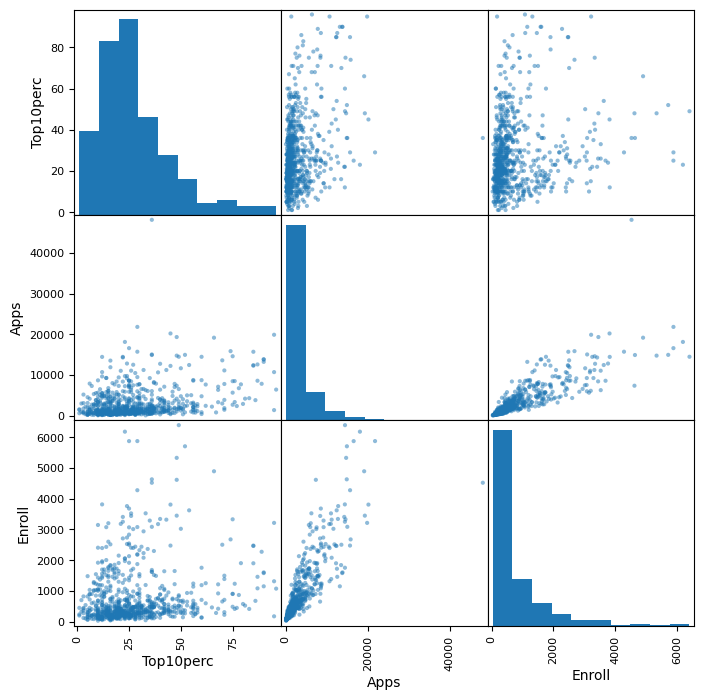

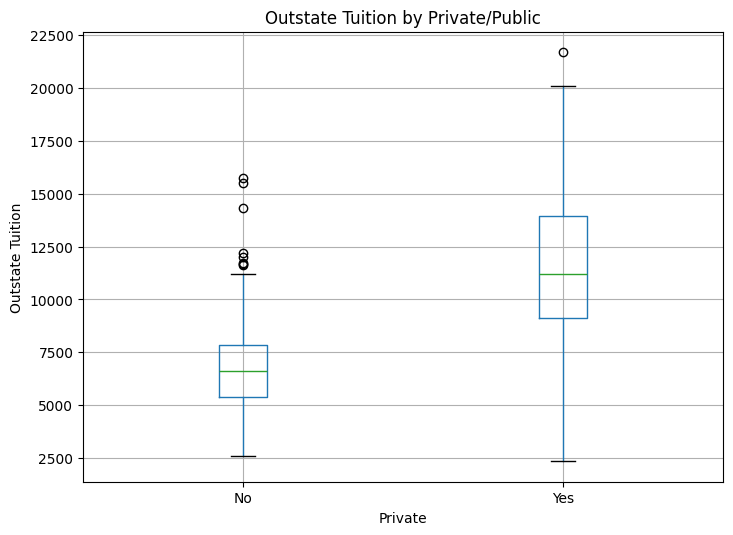

                              Top10perc Elite
Abilene Christian University         23    No
Adelphi University                   16    No
Adrian College                       22    No
Agnes Scott College                  60   Yes
Alaska Pacific University            16    No

Elite Counts:
Elite
No     699
Yes     78
Name: count, dtype: int64


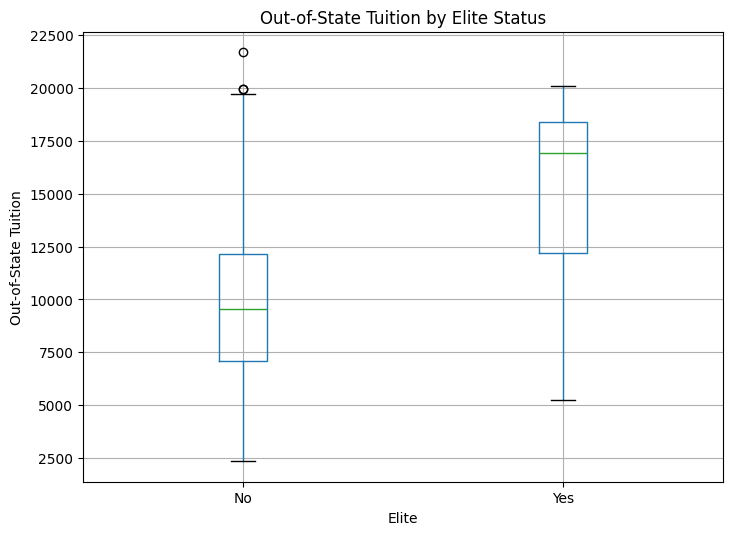

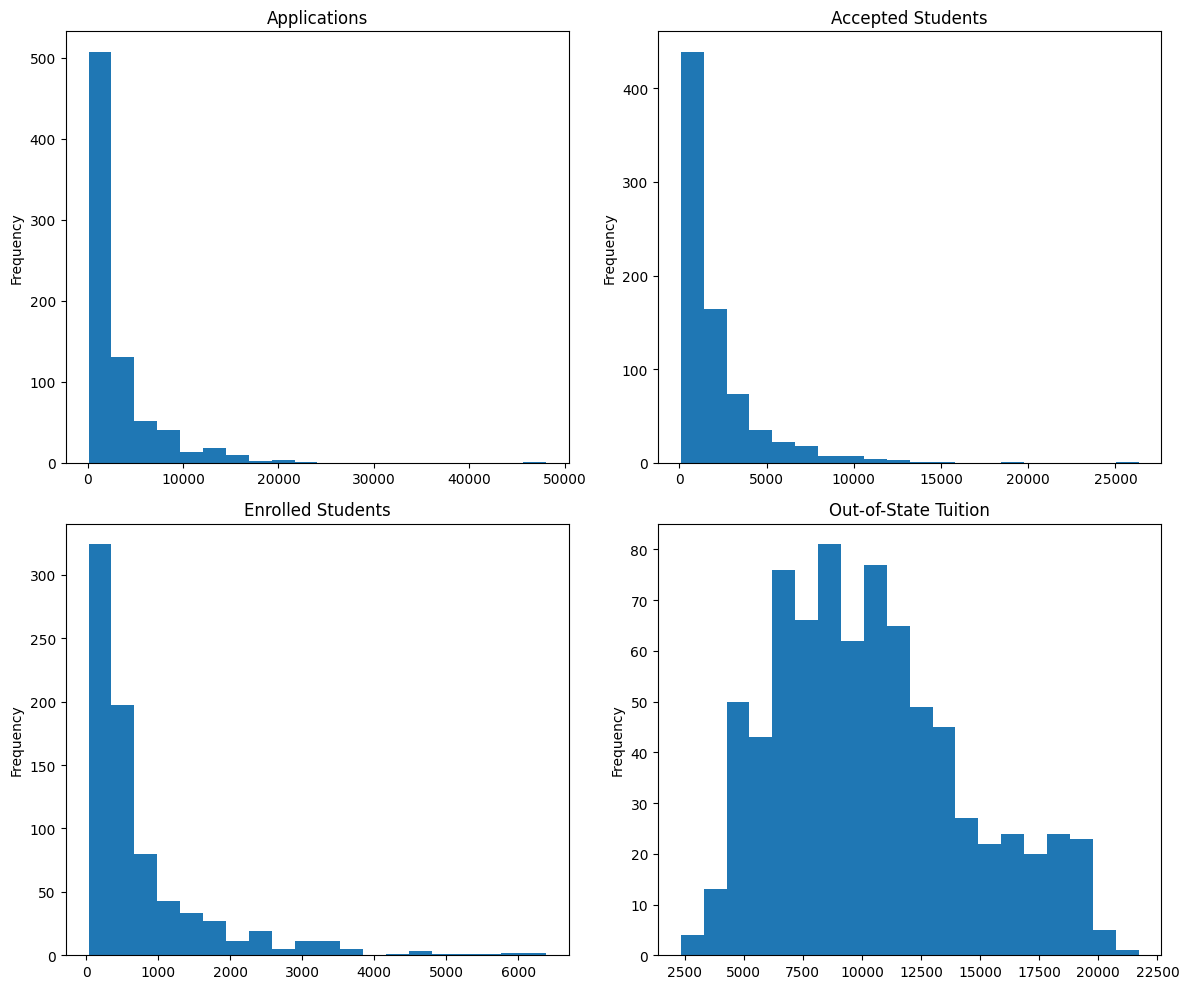

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
# Load dataset from GitHub
url = "https://raw.githubusercontent.com/Reben80/Data201-Fall2026-CRN21732/main/Dataset/College.csv"
college = pd.read_csv(url)

# Display first 5 rows
print(college.head())

# Shape
print("Shape:", college.shape)

# Column names
print("\nColumns:")
print(college.columns)

# Dataset info
print("\nDataset Information:")
college.info()

# ----------------------------------
# (b) Set first column as index
# ----------------------------------
college2 = pd.read_csv(url, index_col=0)
if "Unnamed: 0" in college2.columns:
  college3 = college2.rename(columns={"Unnamed: 0": "College"})
  college3 = college3.set_index("College")
  college = college3
else:
  college = college2
print("\nUpdated DataFrame:")
print(college.head())

# ----------------------------------
# (c) Summary statistics
# ----------------------------------
print("\nSummary Statistics:")
print(college.describe())
# ----------------------------------

# (d) Scatterplot matrix
# ----------------------------------
scatter_matrix(
college[['Top10perc', 'Apps', 'Enroll']],
figsize=(8, 8),
diagonal='hist'
)
plt.show()

# ----------------------------------
# (e) Boxplot
# ----------------------------------
college.boxplot(column='Outstate', by='Private', figsize=(8,6))
plt.title("Outstate Tuition by Private/Public")
plt.suptitle('')
plt.xlabel('Private')
plt.ylabel('Outstate Tuition')
plt.show()

# ----------------------------------
# (f) Create Elite variable
# ----------------------------------
college['Elite'] = pd.cut(
college['Top10perc'],
bins=[0, 50, 100],
labels=['No', 'Yes']
)
# Display the first few rows
print(college[['Top10perc', 'Elite']].head())
# Count the number of Elite and Non-Elite colleges
print("\nElite Counts:")
print(college['Elite'].value_counts())

# Boxplot of Outstate tuition by Elite status
college.boxplot(column='Outstate', by='Elite', figsize=(8, 6))
plt.title('Out-of-State Tuition by Elite Status')
plt.suptitle('') # Removes automatic subtitle
plt.xlabel('Elite')
plt.ylabel('Out-of-State Tuition')
plt.show()


# ----------------------------------
# (g): Histograms of four quantitative variables
# ----------------------------------
# Create a 2x2 grid of histograms
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
college['Apps'].plot.hist(ax=axes[0, 0], bins=20, title='Applications')
college['Accept'].plot.hist(ax=axes[0, 1], bins=20, title='Accepted Students')
college['Enroll'].plot.hist(ax=axes[1, 0], bins=20, title='Enrolled Students')
college['Outstate'].plot.hist(ax=axes[1, 1], bins=20, title='Out-of-State Tuition')
plt.tight_layout()
plt.show()



# The Elite variable separates colleges into two groups based on the percentage of students who graduated in the top 10% of their high school class.
# The boxplot suggests that Elite colleges generally have higher out-of-state tuition than non-Elite colleges.
# The histograms show that variables such as Applications, Acceptances, and Enrollment are right-skewed, indicating that a small number of colleges receive substantially more applications and enroll more students than most colleges.
# Out-of-state tuition also shows considerable variability across institutions.

### Part 2 —Auto DataSet Review

    mpg  cylinders  displacement  horsepower  weight  acceleration  year  \
0  18.0          8         307.0       130.0    3504          12.0    70   
1  15.0          8         350.0       165.0    3693          11.5    70   
2  18.0          8         318.0       150.0    3436          11.0    70   
3  16.0          8         304.0       150.0    3433          12.0    70   
4  17.0          8         302.0       140.0    3449          10.5    70   

   origin                       name  
0       1  chevrolet chevelle malibu  
1       1          buick skylark 320  
2       1         plymouth satellite  
3       1              amc rebel sst  
4       1                ford torino  
Data Types:

mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
year              int64
origin            int64
name             object
dtype: object

Minimum Values:
mpg                9.0
cylinders          3.0
dis

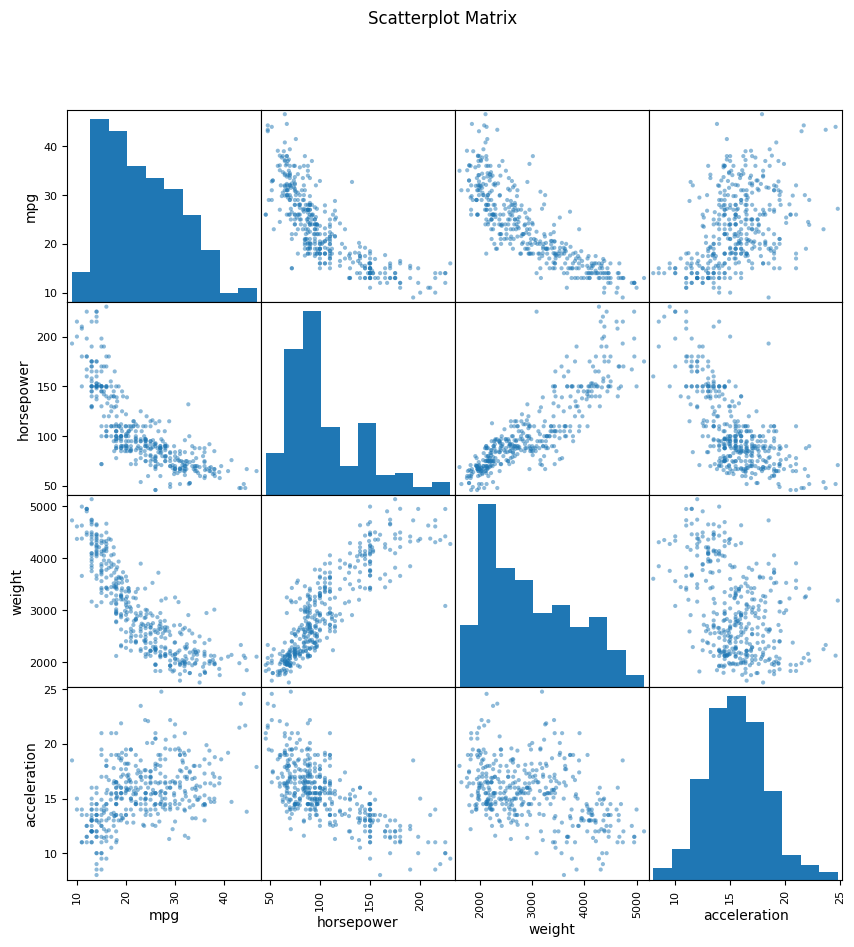

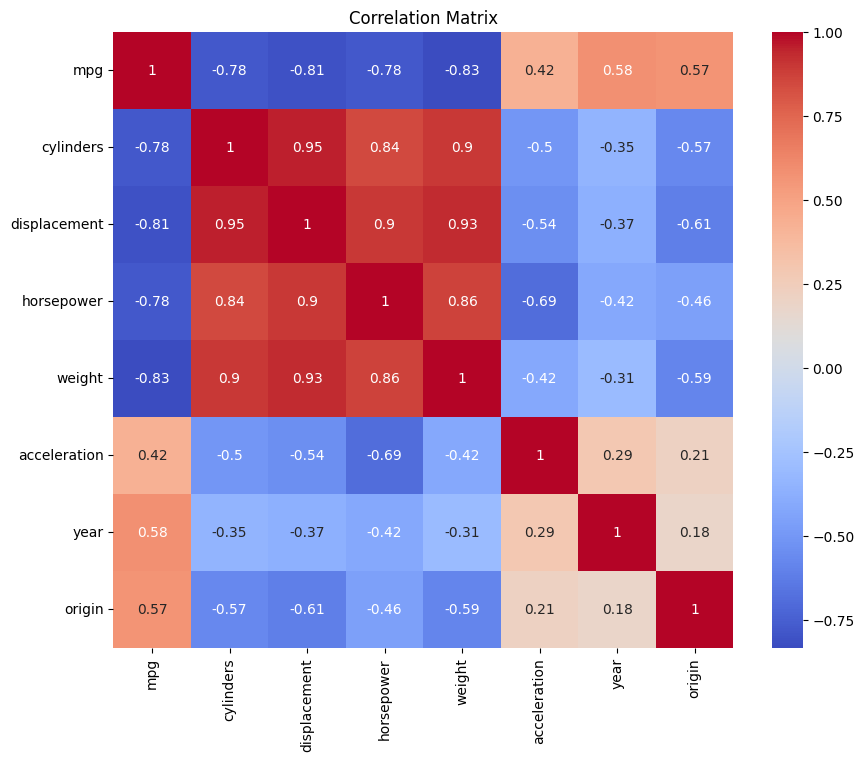

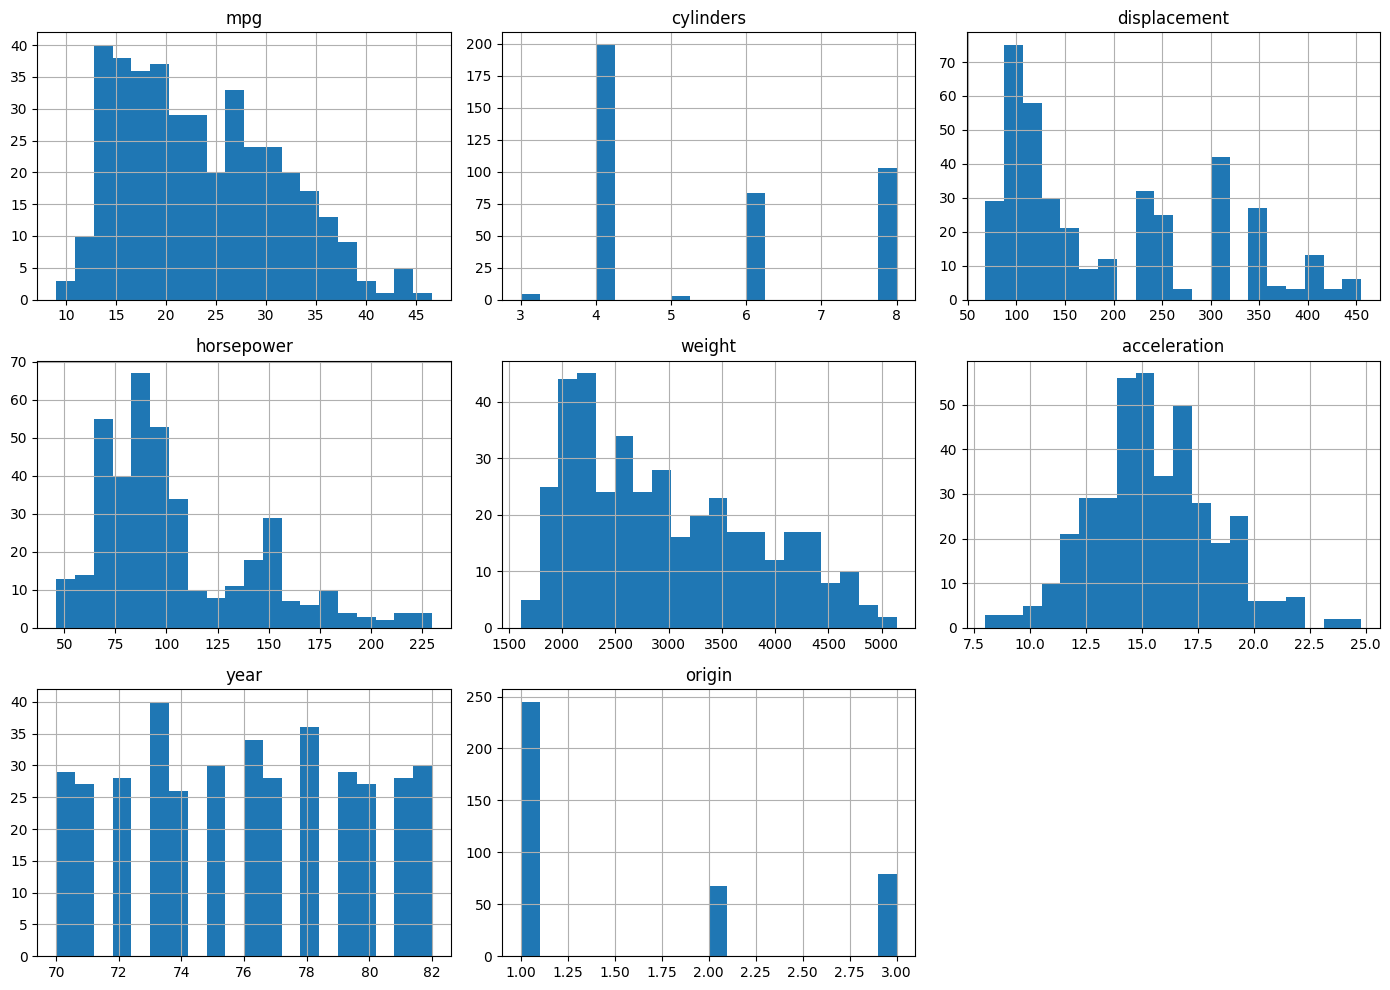


Correlation with MPG:
mpg             1.000000
year            0.580541
origin          0.565209
acceleration    0.423329
cylinders      -0.777618
horsepower     -0.778427
displacement   -0.805127
weight         -0.832244
Name: mpg, dtype: float64


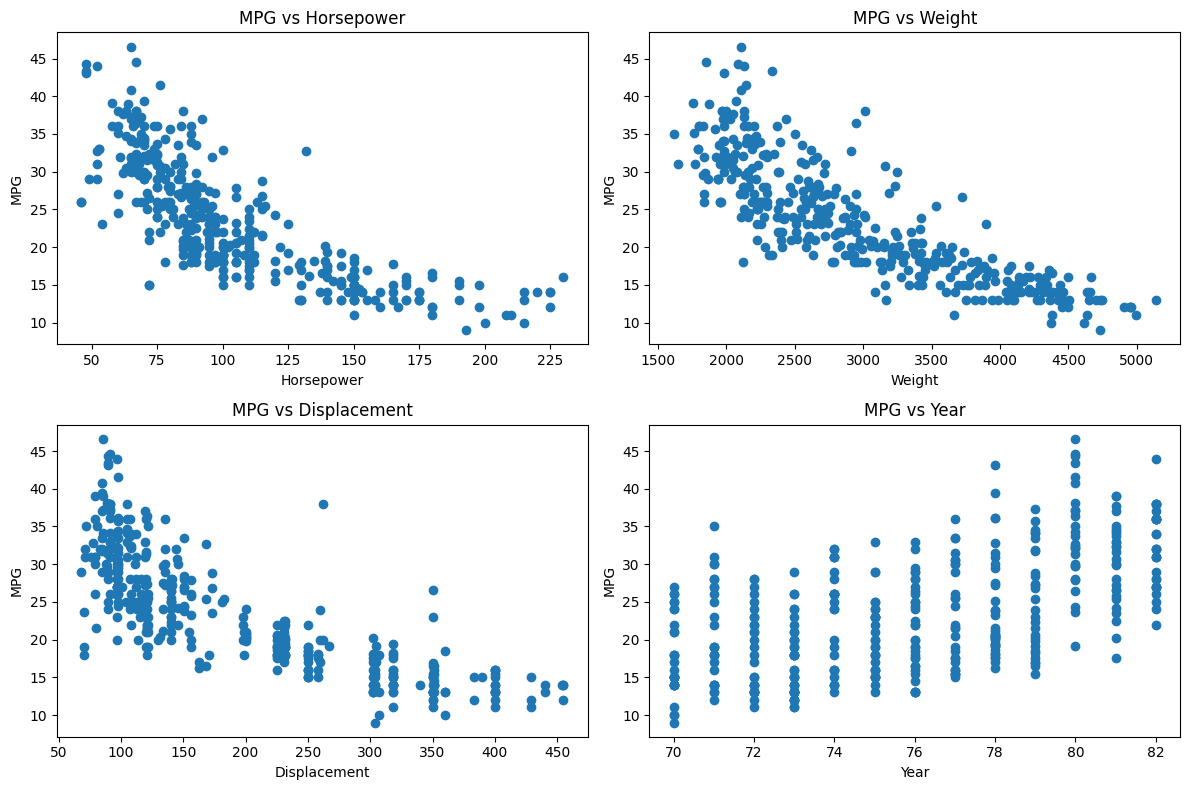

In [21]:
# ==========================================
# Exercise 9 - Auto Dataset
# ==========================================

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
import seaborn as sns

# Load the Auto dataset
url = "https://raw.githubusercontent.com/Reben80/Data201-Fall2026-CRN21732/main/week-02/Auto.csv"
auto = pd.read_csv(url, na_values="?")

# Remove missing values
auto = auto.dropna()
print(auto.head())

# ==========================================
# (a) Quantitative and Qualitative Variables
# ==========================================
print("Data Types:\n")
print(auto.dtypes)


# ==========================================
# (b) Range of each quantitative predictor
# ==========================================
numeric_cols = auto.select_dtypes(include=np.number)
print("\nMinimum Values:")
print(numeric_cols.min())
print("\nMaximum Values:")
print(numeric_cols.max())
print("\nRange:")
print(numeric_cols.max() - numeric_cols.min())

# ==========================================
# (c) Mean and Standard Deviation
# ==========================================
print("\nMeans:")
print(numeric_cols.mean())
print("\nStandard Deviations:")
print(numeric_cols.std())

# ==========================================
# (d) Remove observations 10 through 85
# ==========================================
auto_subset = auto.drop(auto.index[10:86])
subset_numeric = auto_subset.select_dtypes(include=np.number)
print("\n===== AFTER REMOVING ROWS 10-85 =====")
print("\nMinimum Values:")
print(subset_numeric.min())
print("\nMaximum Values:")
print(subset_numeric.max())
print("\nRange:")
print(subset_numeric.max() - subset_numeric.min())
print("\nMeans:")
print(subset_numeric.mean())
print("\nStandard Deviations:")
print(subset_numeric.std())

# ==========================================
# (e) Graphical Investigation
# ==========================================
# Scatterplot matrix
scatter_matrix(
  auto[['mpg', 'horsepower', 'weight', 'acceleration']],
  figsize=(10,10),
  diagonal='hist'
)
plt.suptitle("Scatterplot Matrix")
plt.show()

# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(
  auto.corr(numeric_only=True),
  annot=True,
  cmap='coolwarm'
)
plt.title("Correlation Matrix")
plt.show()

# Histograms
auto.hist(figsize=(14,10), bins=20)
plt.tight_layout()
plt.show()

# ==========================================
# (f) Variables Useful for Predicting MPG
# ==========================================
print("\nCorrelation with MPG:")
print(
  auto.corr(numeric_only=True)['mpg']
  .sort_values(ascending=False)
)

# Scatterplots against MPG
fig, axes = plt.subplots(2, 2, figsize=(12,8))
axes[0,0].scatter(auto['horsepower'], auto['mpg'])
axes[0,0].set_title('MPG vs Horsepower')
axes[0,0].set_xlabel('Horsepower')
axes[0,0].set_ylabel('MPG')

axes[0,1].scatter(auto['weight'], auto['mpg'])
axes[0,1].set_title('MPG vs Weight')
axes[0,1].set_xlabel('Weight')
axes[0,1].set_ylabel('MPG')

axes[1,0].scatter(auto['displacement'], auto['mpg'])
axes[1,0].set_title('MPG vs Displacement')
axes[1,0].set_xlabel('Displacement')
axes[1,0].set_ylabel('MPG')

axes[1,1].scatter(auto['year'], auto['mpg'])
axes[1,1].set_title('MPG vs Year')
axes[1,1].set_xlabel('Year')
axes[1,1].set_ylabel('MPG')

plt.tight_layout()
plt.show()

# (e)  The scatterplots and heatmap show strong relationships among several variables. Weight, displacement, horsepower, and cylinders tend to be highly correlated.

# (f)  The variables most useful for predicting mpg are:
#weight (strong negative relationship)
#horsepower (strong negative relationship)
#displacement (strong negative relationship)
#cylinders (negative relationship)
#year (positive relationship)
#Cars that are lighter, have lower horsepower and displacement, and are newer generally achieve higher gas mileage.

**Data Types**

* **Tuple:** Heterogeneous. It can store a mix of different data types (strings, numbers, booleans) together.
* **Array:** Homogeneous. Every element must be of the exact same data type.

**Mutability**

* **Tuple:** Immutable. Elements cannot be altered, added, or removed after creation.
* **Array:** Mutable. Individual elements can be modified, though total size is often fixed.

**Common Analogy**

* **Tuple:** Works like a database record or a lightweight struct with fixed positions.
* **Array:** Works like a mathematical vector or a simple inventory list.


### Part 3 — Boston Housing Review

   Unnamed: 0     crim    zn  indus  chas    nox     rm   age     dis  rad  \
0           1  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1   
1           2  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2   
2           3  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2   
3           4  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3   
4           5  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3   

   tax  ptratio  lstat  medv  
0  296     15.3   4.98  24.0  
1  242     17.8   9.14  21.6  
2  242     17.8   4.03  34.7  
3  222     18.7   2.94  33.4  
4  222     18.7   5.33  36.2  

Shape of Dataset:
(506, 14)

Number of Rows: 506
Number of Columns: 14

Column Names:
Index(['Unnamed: 0', 'crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis',
       'rad', 'tax', 'ptratio', 'lstat', 'medv'],
      dtype='object')


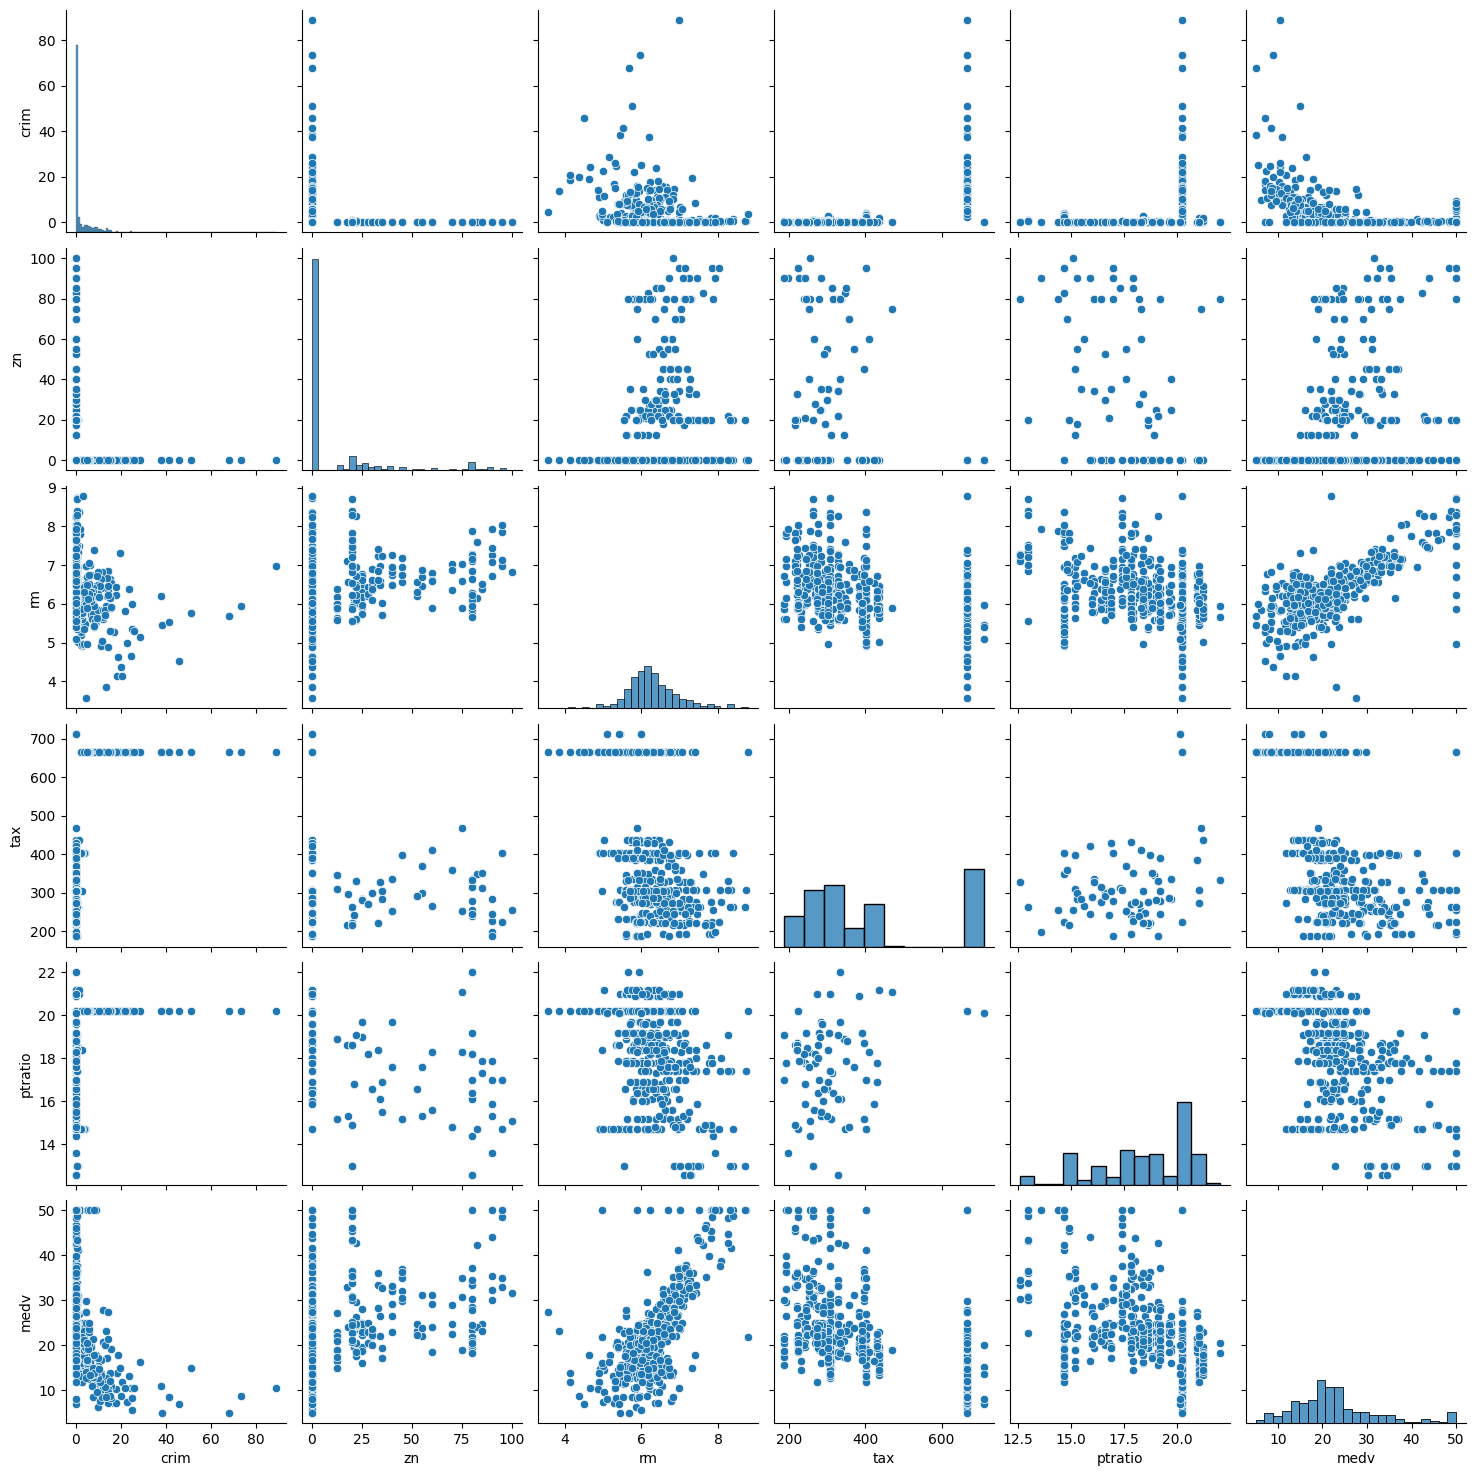


Correlation with CRIM:
crim          1.000000
rad           0.625505
tax           0.582764
lstat         0.455621
nox           0.420972
Unnamed: 0    0.407407
indus         0.406583
age           0.352734
ptratio       0.289946
chas         -0.055892
zn           -0.200469
rm           -0.219247
dis          -0.379670
medv         -0.388305
Name: crim, dtype: float64


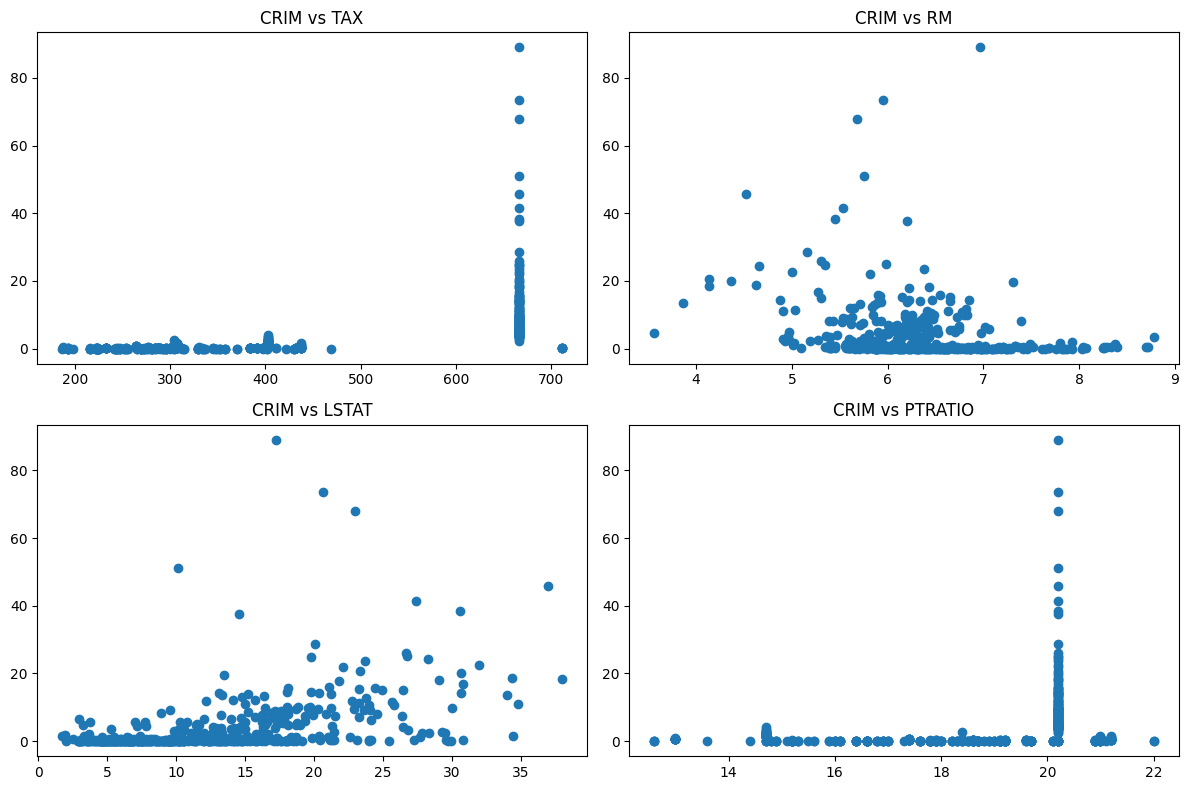


Minimum Values:
Unnamed: 0      1.00000
crim            0.00632
zn              0.00000
indus           0.46000
chas            0.00000
nox             0.38500
rm              3.56100
age             2.90000
dis             1.12960
rad             1.00000
tax           187.00000
ptratio        12.60000
lstat           1.73000
medv            5.00000
dtype: float64

Maximum Values:
Unnamed: 0    506.0000
crim           88.9762
zn            100.0000
indus          27.7400
chas            1.0000
nox             0.8710
rm              8.7800
age           100.0000
dis            12.1265
rad            24.0000
tax           711.0000
ptratio        22.0000
lstat          37.9700
medv           50.0000
dtype: float64

Range:
Unnamed: 0    505.00000
crim           88.96988
zn            100.00000
indus          27.28000
chas            1.00000
nox             0.48600
rm              5.21900
age            97.10000
dis            10.99690
rad            23.00000
tax           524.00000
ptrati

In [24]:
# ==========================================
# Exercise 10 - Boston Housing Dataset
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Boston dataset
url = "https://raw.githubusercontent.com/Reben80/Data201-Fall2026-CRN21732/main/Dataset/Boston.csv"
boston = pd.read_csv(url)

# Display first few rows
print(boston.head())

# ==========================================
# (b) Number of rows and columns
# ==========================================
print("\nShape of Dataset:")
print(boston.shape)
print("\nNumber of Rows:", boston.shape[0])
print("Number of Columns:", boston.shape[1])
print("\nColumn Names:")
print(boston.columns)

# ==========================================
# (c) Pairwise Scatterplots
# ==========================================
sns.pairplot(
boston[['crim', 'zn', 'rm', 'tax', 'ptratio', 'medv']]
)
plt.show()

# ==========================================
# (d) Predictors associated with crime rate
# ==========================================
corr = boston.corr(numeric_only=True)
print("\nCorrelation with CRIM:")
print(corr['crim'].sort_values(ascending=False))
# Scatterplots against crime rate
fig, axes = plt.subplots(2, 2, figsize=(12,8))
axes[0,0].scatter(boston['tax'], boston['crim'])
axes[0,0].set_title('CRIM vs TAX')
axes[0,1].scatter(boston['rm'], boston['crim'])
axes[0,1].set_title('CRIM vs RM')
axes[1,0].scatter(boston['lstat'], boston['crim'])
axes[1,0].set_title('CRIM vs LSTAT')
axes[1,1].scatter(boston['ptratio'], boston['crim'])
axes[1,1].set_title('CRIM vs PTRATIO')
plt.tight_layout()
plt.show()

# ==========================================
# (e) Range of each predictor
# ==========================================
print("\nMinimum Values:")
print(boston.min())
print("\nMaximum Values:")
print(boston.max())
print("\nRange:")
print(boston.max(numeric_only=True) -
boston.min(numeric_only=True))
# High Crime Rate Suburbs
print("\nTop 10 Crime Rates:")
print(boston['crim'].sort_values(ascending=False).head(10))
# High Tax Rates
print("\nTop 10 Tax Rates:")
print(boston['tax'].sort_values(ascending=False).head(10))
# High Pupil-Teacher Ratios
print("\nTop 10 PTRATIO Values:")
print(boston['ptratio'].sort_values(ascending=False).head(10))

# ==========================================
# (f) Number of suburbs bordering Charles River
# ==========================================
print("\nSuburbs bordering Charles River:")
print((boston['chas'] == 1).sum())

# ==========================================
# (g) Median pupil-teacher ratio
# ==========================================
print("\nMedian PTRATIO:")
print(boston['ptratio'].median())

# ==========================================
# (h) Suburb with lowest MEDV
# ==========================================
lowest_medv = boston.loc[boston['medv'].idxmin()]
print("\nSuburb with Lowest MEDV:")
print(lowest_medv)

# ==========================================
# (i) Towns with more than 7 rooms
# ==========================================
more_than_7 = boston[boston['rm'] > 7]
print("\nTowns with RM > 7:")
print(more_than_7.shape[0])

# Towns with more than 8 rooms
more_than_8 = boston[boston['rm'] > 8]
print("\nTowns with RM > 8:")
print(more_than_8.shape[0])
print("\nDetails of Towns with RM > 8:")
print(more_than_8)